<a href="https://www.kaggle.com/code/vickysen/medical-insurance-prediction-eda?scriptVersionId=263341507" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background-color: maroon; color: white; font-family: 'Times New Roman', Times, serif; font-weight: bold; font-size: 30px; padding: 10px; border-radius: 5px; text-align: center;">
  Medical Insurance Data Visualisation and Prediction
</div>


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/medical-insurance-cost-dataset/insurance.csv


In [2]:
# Ignoring unnecessary warnings

import warnings
warnings.filterwarnings("ignore") # Suppress all warnings

In [3]:
# Loading important library

import matplotlib.pyplot as plt
import seaborn as sns

# rest libraries will be imported when required

In [4]:
df=pd.read_csv('/kaggle/input/medical-insurance-cost-dataset/insurance.csv')

In [5]:
# View the first few rows
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [6]:
# Check the shape (rows and columns)
print(df.shape)

(1338, 7)


> We have 1338 ros and 7 columns

In [7]:
# List all column names
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [8]:
# Check data types of each column
print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [9]:
# Check for missing values
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


> There is no missing data in our dataset

In [10]:
# Get summary statistics for numerical columns
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [11]:
# Checking for duplicated rows

duplicates = df[df.duplicated()]
duplicates

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [12]:
# Printing all Duplicates (Not Just the Second Occurrence)
duplicates_all = df[df.duplicated(keep=False)]
duplicates_all

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [13]:
# Remove Duplicates
df = df.drop_duplicates()
df.head(2) 

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


In [14]:
# Check Duplicates Based on Specific Columns
# df[df.duplicated(subset=['Name', 'Age'], keep=False)]

# Count Duplicates
# total_duplicates = df.duplicated().sum()

### Checking for outliers

<Axes: xlabel='age'>

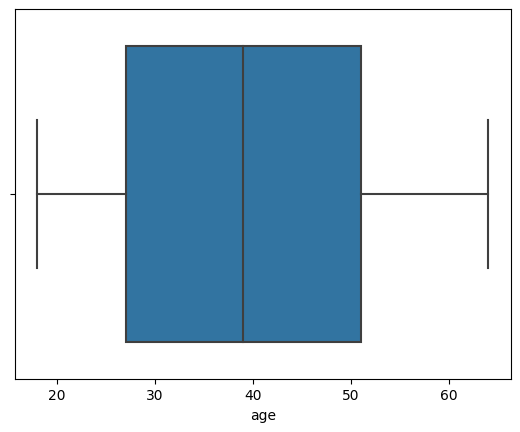

In [15]:
sns.boxplot(x='age',data=df)

<Axes: xlabel='bmi'>

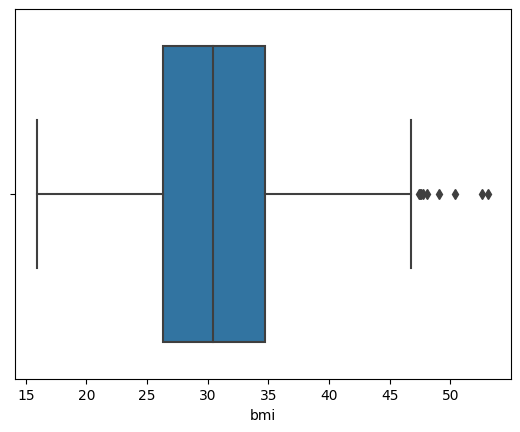

In [16]:
sns.boxplot(x='bmi',data=df)

These high BMI values ahead 45 may represent actual individuals (e.g., extreme obesity), keeping them helps reflect the true population. SO we are not removing thesre, this graph was just for illustraion.

<Axes: xlabel='children'>

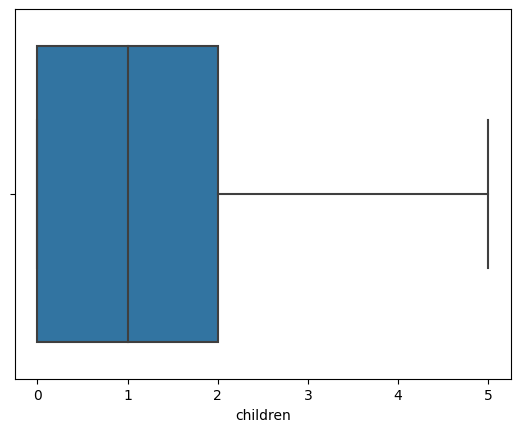

In [17]:
sns.boxplot(x='children',data=df)

<div style="background-color: maroon; color: white; font-family: 'Times New Roman', Times, serif; font-weight: bold; font-size: 26px; padding: 10px; border-radius: 5px; text-align: center;">
  Data Visualization
</div>


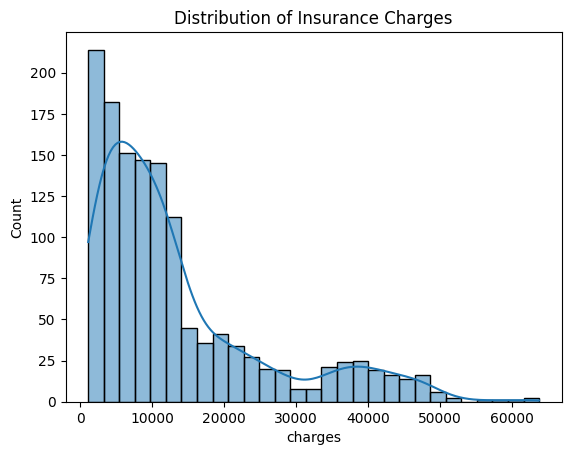

In [18]:
# Distribution of Charges
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

> The histogram and density plot show a strong right skew. That means most individuals have relatively low insurance charges, while a small number incur very high costs. This is typical in healthcare data, where a few patients may require expensive treatments.

>High Concentration Below ₹20,000 (or $20,000): The tallest bars are in the lower charge ranges, indicating that the majority of people fall into the low-cost bracket. This could reflect routine medical expenses or preventive care

>The tail extending beyond ₹60,000 suggests outliers or high-risk individuals—possibly those with chronic conditions, surgeries, or intensive care needs. 

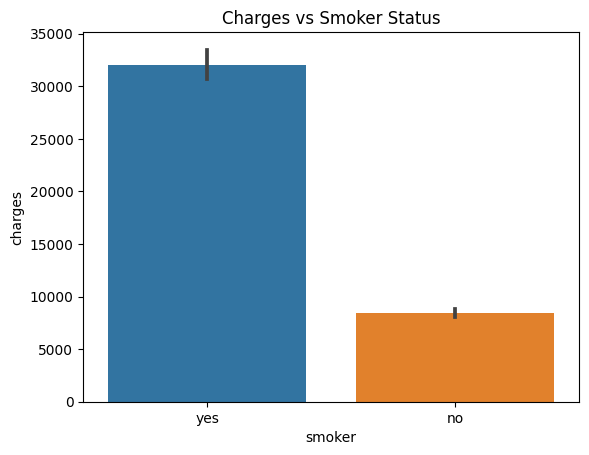

In [19]:
# Charges by Smoking Status
sns.barplot(x='smoker', y='charges', data=df)
plt.title('Charges vs Smoker Status')
plt.show()

>Smokers Pay Significantly More The average medical charges for smokers are dramatically higher—well over 30,000—compared to non-smokers, who average around 8,000. That’s nearly a 4x increase.

>For Insurance Companies: Smoking status is a critical variable in risk assessment. Smokers may be charged higher premiums to offset the anticipated costs.

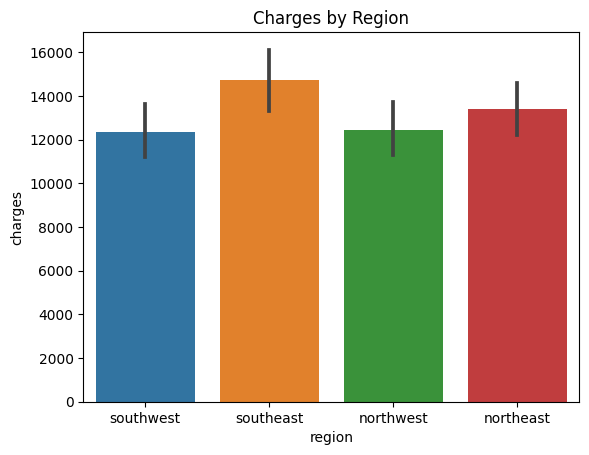

In [20]:
#  charges by region

sns.barplot(x='region', y='charges', data=df)
plt.title('Charges by Region')
plt.show()

The Southeast region has the highest average medical charges, suggesting either:
- Higher healthcare costs in that area
- A population with more health issues or risk factors (e.g., higher smoking rates, obesity, etc.)
- Greater access to expensive medical services

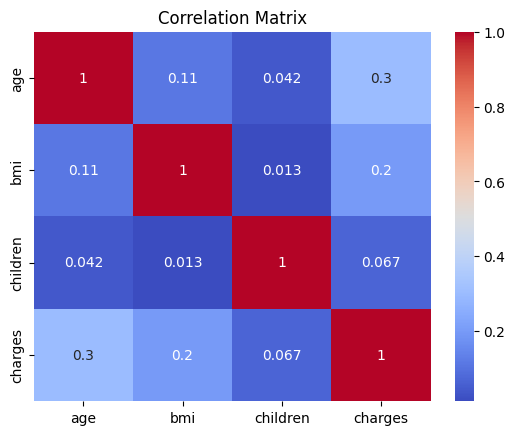

In [21]:
# Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Here is a few inside from correlation matrix:

- Age vs Charges (0.3): Moderate positive correlation — older people tend to have higher medical costs.
- BMI vs Charges (0.2): Slight positive correlation — higher BMI may lead to increased charges, possibly due to obesity-related health issues.
- Children vs Charges (0.068): Very weak correlation — having more children doesn’t significantly affect medical charges.
- Age vs BMI (0.11): Minimal relationship — age and BMI don’t strongly influence each other.

<div style="background-color: maroon; color: white; font-family: 'Times New Roman', Times, serif; font-weight: bold; font-size: 26px; padding: 10px; border-radius: 5px; text-align: center;">
  Model Building
</div>


> As ML algorithm accepts only numerical data, So before going further we need to convert all categorical data into numerical

In [22]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

# Check for missing values
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [23]:
df.head(4)

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061


In [24]:
from sklearn.model_selection import train_test_split

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", mean_squared_error(y_test, y_pred_lr, squared=False))

Linear Regression R²: 0.8068466322629111
Linear Regression RMSE: 5957.60879981646


In [26]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", mean_squared_error(y_test, y_pred_rf, squared=False))


Random Forest R²: 0.882860500101962
Random Forest RMSE: 4639.514354434764


In [27]:
# Gradient Boosting Regressor (GBR)
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

print("Gradient Boosting R²:", r2_score(y_test, y_pred_gbr))
print("Gradient Boosting RMSE:", mean_squared_error(y_test, y_pred_gbr, squared=False))


Gradient Boosting R²: 0.901117499430293
Gradient Boosting RMSE: 4262.658689976379


In [28]:
# XGBoost Regressor
import xgboost as xgb

xgb_model = xgb.XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost R²:", r2_score(y_test, y_pred_xgb))
print("XGBoost RMSE:", mean_squared_error(y_test, y_pred_xgb, squared=False))


XGBoost R²: 0.8675872476172524
XGBoost RMSE: 4932.711851172984


In [29]:
# LightGBM Regressor
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(random_state=42)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

print("LightGBM R²:", r2_score(y_test, y_pred_lgb))
print("LightGBM RMSE:", mean_squared_error(y_test, y_pred_lgb, squared=False))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 316
[LightGBM] [Info] Number of data points in the train set: 1069, number of used features: 6
[LightGBM] [Info] Start training from score 13030.203373
LightGBM R²: 0.8844909909016905
LightGBM RMSE: 4607.111988349416


In [30]:
# Comparing all models

comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'LightGBM'
    ],
    'R² Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gbr),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_lgb)
    ],
    'RMSE': [
        mean_squared_error(y_test, y_pred_lr, squared=False),
        mean_squared_error(y_test, y_pred_rf, squared=False),
        mean_squared_error(y_test, y_pred_gbr, squared=False),
        mean_squared_error(y_test, y_pred_xgb, squared=False),
        mean_squared_error(y_test, y_pred_lgb, squared=False)
    ]
})

# Sort by R² Score descending
comparison_df = comparison_df.sort_values(by='R² Score', ascending=False)
print(comparison_df)

               Model  R² Score         RMSE
2  Gradient Boosting  0.901117  4262.658690
4           LightGBM  0.884491  4607.111988
1      Random Forest  0.882861  4639.514354
3            XGBoost  0.867587  4932.711851
0  Linear Regression  0.806847  5957.608800


> Here we can notice that gradient boosting has given the best R² Score of 0.901117, a value near one indicates good fitting model, a value more close to zero indicates a bad fitting model.

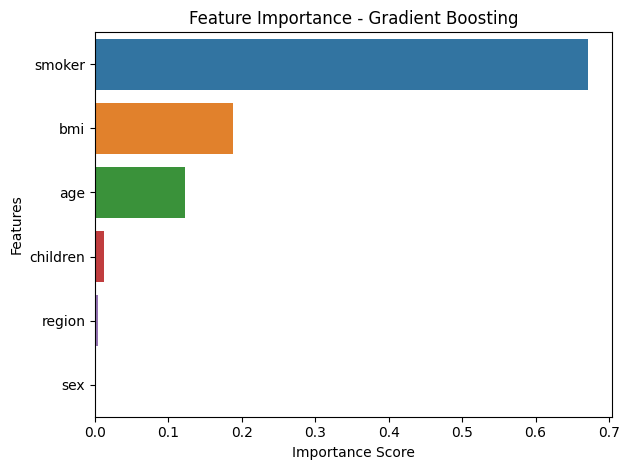

In [31]:

# Visualisation of feature importances

feature_importance = pd.Series(gbr.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Hyperparameter tuning

In [32]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3]
}
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=gbr,  # your existing model
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("✅ Best Parameters:", grid_search.best_params_)
print("📉 Best RMSE:", (-grid_search.best_score_)**0.5)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
✅ Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 1.0}
📉 Best RMSE: 4616.052972835319


In [33]:
best_gbr = grid_search.best_estimator_
y_pred_best = best_gbr.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error
print("Tuned GBR R²:", r2_score(y_test, y_pred_best))
print("Tuned GBR MAE:", mean_absolute_error(y_test, y_pred_best))


Tuned GBR R²: 0.9016600553394905
Tuned GBR MAE: 2485.66242299129


> Here we can notice that, Even after hyperparameter Tuning no major changes detected n R2 score. Previously it Was 0.901117, after tuning it got to 0.901660 only.

In [34]:
# let’s wrap your tuned Gradient Boosting model into a Streamlit app

! pip install streamlit
import joblib
# Save the best model
joblib.dump(best_gbr, 'gbr_model.pkl')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 73.9 MB/s eta 0:00:00


['gbr_model.pkl']

In [35]:
import streamlit as st
import joblib
import numpy as np

# Load model
model = joblib.load('gbr_model.pkl')

# App title
st.title("Medical Insurance Charges Predictor")

# Input fields
age = st.slider("Age", 18, 100, 30)
sex = st.selectbox("Sex", ["Male", "Female"])
bmi = st.number_input("BMI", min_value=10.0, max_value=50.0, value=25.0)
children = st.slider("Number of Children", 0, 5, 1)
smoker = st.selectbox("Smoker", ["Yes", "No"])
region = st.selectbox("Region", ["Southwest", "Southeast", "Northwest", "Northeast"])

# Encode inputs
sex_encoded = 1 if sex == "Male" else 0
smoker_encoded = 1 if smoker == "Yes" else 0
region_map = {"Southwest": 3, "Southeast": 2, "Northwest": 1, "Northeast": 0}
region_encoded = region_map[region]

# Predict
if st.button("Predict Charges"):
    input_data = np.array([[age, sex_encoded, bmi, children, smoker_encoded, region_encoded]])
    prediction = model.predict(input_data)[0]
    st.success(f"Estimated Insurance Charges: ₹{prediction:,.2f}")


2025-09-22 12:51:24.379 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-22 12:51:24.668 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-09-22 12:51:24.669 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-22 12:51:24.670 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-22 12:51:24.670 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-22 12:51:24.671 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-22 12:51:24.672 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-22 12:51:24.673 Thread 'MainThread': mi

- You can build and test this model here on Kaggle
- Then download the trained model (.pkl file)
- Run the Streamlit app locally on your machine or deploy it to Streamlit Cloud, Heroku, or Render.

Once you upload your app and model file (gbr_model.pkl) or anyone of yours to Streamlit Cloud (via GitHub), the app runs on their servers — not your local machine. So:

- Deleting your local file won’t affect the deployed app.
- As long as the model file is present in the GitHub repo linked to your Streamlit app, it will continue to work.
- Anyone with the link can access and use the app, even if your local files are gone.